# Deep dive: single-gene exploration across all manipulations

Pick one gene and walk through:

1. The **raw forward-strand SEQ** field as stored in `datafile_test_0.h5`, including its 5 kb flank.
2. The **sense-strand sequence** that the encoder actually sees (= rev-comp for `−` strand).
3. The **exon/intron table** in sense coords.
4. The **concatenated exonic content** (the "spliced mRNA" — what gets shuffled / deleted from).
5. **Side-by-side comparisons** of that exonic content across all 5 states (text + chart).
6. The **encoded one-hot input** the model receives, including a heatmap around a junction.

> **About CDS:** the SpliceAI datafile does not store CDS (start codon → stop codon) coordinates. Where this notebook says "CDS-like" we mean the **concatenated exonic content** — the assembled mRNA — which is the actual sequence the manipulations operate on. If you have real CDS coords, set `CDS_SPAN` in the relevant cell.

In [1]:
from __future__ import annotations
import json
import sys
from collections import Counter
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import HTML, display

REPO_ROOT = Path('..').resolve()
sys.path.insert(0, str(REPO_ROOT / 'experiments'))
from manipulate_exons import build_exon_spans, gene_to_sense, get_gene_record
from encode_datafile import encode_one_gene, build_label_string, create_datapoints

MODES = ['original', 'nt_shuffle', 'codon_shuffle', 'remove1', 'remove2']
DATAFILES = {
    'original':       REPO_ROOT / 'datafile_test_0.h5',
    'nt_shuffle':     REPO_ROOT / 'datafile_test_nt_shuffle.h5',
    'codon_shuffle':  REPO_ROOT / 'datafile_test_codon_shuffle.h5',
    'remove1':        REPO_ROOT / 'datafile_test_remove1.h5',
    'remove2':        REPO_ROOT / 'datafile_test_remove2.h5',
}
MANIFESTS = {m: REPO_ROOT / f'datafile_test_{m}.h5.manifest.json'
             for m in ('nt_shuffle', 'codon_shuffle', 'remove1', 'remove2')}

In [2]:
# Choose your gene here -------------------------------------------------
GENE_NAME = 'AZIN2'   # try also 'LIN9' (− strand, 14 introns, ~78 kb)
# ----------------------------------------------------------------------

def find_gene_index(datafile_path: Path, name: str) -> int:
    with h5py.File(datafile_path, 'r') as f:
        for i, n in enumerate(f['NAME'][:]):
            if n.decode() == name:
                return i
    raise KeyError(f'{name!r} not found in {datafile_path}')

GENE_IDX = find_gene_index(DATAFILES['original'], GENE_NAME)
print(f'{GENE_NAME} → gene index {GENE_IDX}')

def load_record(mode: str, gene_idx: int) -> dict:
    with h5py.File(DATAFILES[mode], 'r') as f:
        rec = get_gene_record(f, gene_idx)
    sense, donors, acceptors = gene_to_sense(rec)
    rec['sense'] = sense
    rec['donors'] = donors
    rec['acceptors'] = acceptors
    rec['exons'] = build_exon_spans(donors, acceptors,
                                    rec['gene_offset'],
                                    rec['gene_offset'] + rec['gene_len'])
    return rec

records = {m: load_record(m, GENE_IDX) for m in MODES}
orig = records['original']
print(f"strand={orig['strand']}  TX=[{orig['tx_start']:,}, {orig['tx_end']:,})  "
      f"gene_len={orig['gene_len']:,}  #exons={len(orig['exons'])}  #introns={len(orig['donors'])}")

AZIN2 → gene index 0
strand=+  TX=[33,546,714, 33,585,995)  gene_len=39,281  #exons=12  #introns=11


## 1. Raw forward-strand SEQ (as stored on disk)

Layout: `5000 bp left flank | gene_len + 1 bp | 5000 bp right flank` (the +1 is a SpliceAI-original quirk; for `−` strand it ends up at sense[0] after rev-comp, for `+` strand at sense[-1]).

In [3]:
seq_full = orig['seq_full']
flank_l = orig['flank']
sense_len = orig['sense_len']
gene_start_in_seq = flank_l
gene_end_in_seq = flank_l + sense_len
right_flank_len = len(seq_full) - gene_end_in_seq

print(f"seq_full length: {len(seq_full):,} bp  =  left flank {flank_l} + extended gene {sense_len} + right flank {right_flank_len}")
print(f"  Last 30 bp of left flank:  …{seq_full[flank_l-30:flank_l]}|")
print(f"  First 30 bp of gene:        |{seq_full[flank_l:flank_l+30]}…")
print(f"  Last 30 bp of gene:        …{seq_full[gene_end_in_seq-30:gene_end_in_seq]}|")
print(f"  First 30 bp of right flank: |{seq_full[gene_end_in_seq:gene_end_in_seq+30]}…")

seq_full length: 49,282 bp  =  left flank 5000 + extended gene 39282 + right flank 5000
  Last 30 bp of left flank:  …AGGTAGGGCCTCGGCACTATGGGCGGGGCC|
  First 30 bp of gene:        |TGGGCGGGGTTATATAAGCCAGCGGCGGGC…
  Last 30 bp of gene:        …AAGTATGCAACATAAATCCTGTTCCTTCCA|
  First 30 bp of right flank: |GCTGTGTCTGCCTCCTCTGCAGTGCAAGGG…


## 2. Sense-strand sequence (what the encoder feeds the model)

For `+` strand: sense = forward (no rev-comp). For `−` strand: sense = reverse-complement of the gene region.

In [4]:
sense = orig['sense']
print(f"sense length: {len(sense):,} bp  (gene_offset={orig['gene_offset']}, so gene-proper occupies sense[{orig['gene_offset']}:{orig['gene_offset']+orig['gene_len']}])")
print()
print(f"  Forward gene start: {seq_full[flank_l:flank_l+30]}")
print(f"  Sense  gene start : {sense[:30]}{'  (rev-comped)' if orig['strand'] == '-' else '  (= forward)'}")
print()
print(f"  Forward gene end:  {seq_full[gene_end_in_seq-30:gene_end_in_seq]}")
print(f"  Sense  gene end :  {sense[-30:]}")

sense length: 39,282 bp  (gene_offset=0, so gene-proper occupies sense[0:39281])

  Forward gene start: TGGGCGGGGTTATATAAGCCAGCGGCGGGC
  Sense  gene start : TGGGCGGGGTTATATAAGCCAGCGGCGGGC  (= forward)

  Forward gene end:  AAGTATGCAACATAAATCCTGTTCCTTCCA
  Sense  gene end :  AAGTATGCAACATAAATCCTGTTCCTTCCA


## 3. Exon / intron table

All coordinates in **sense** space. Donor = last exon nt of the upstream exon (intron starts at d+1 with the GT motif). Acceptor = first exon nt of the downstream exon (intron ends at a−1 with the AG motif).

In [5]:
exons = orig['exons']
donors = orig['donors']
acceptors = orig['acceptors']
rows = []
for i, (s, e) in enumerate(exons):
    rows.append(('exon', i + 1, s, e, e - s, ''))
    if i < len(donors):
        d = donors[i]; a = acceptors[i]
        intron_start = d + 1
        intron_end = a  # exclusive
        motif5 = sense[d+1:d+3]
        motif3 = sense[a-2:a]
        rows.append(('intron', i + 1, intron_start, intron_end, intron_end - intron_start,
                     f"{motif5}…{motif3}"))

print(f"{'kind':<7}{'#':>4}  {'start':>8}{'end':>8}{'length':>10}    motif")
print('-' * 60)
for kind, i, s, e, ln, motif in rows:
    print(f"{kind:<7}{i:>4}  {s:>8}{e:>8}{ln:>10}    {motif}")

total_exonic = sum(e - s for s, e in exons)
total_intronic = sum(a - d - 1 for d, a in zip(donors, acceptors))
print()
print(f"Σ exonic = {total_exonic:,} bp  ({100*total_exonic/orig['gene_len']:.1f}% of gene)")
print(f"Σ intronic = {total_intronic:,} bp  ({100*total_intronic/orig['gene_len']:.1f}% of gene)")

kind      #     start     end    length    motif
------------------------------------------------------------
exon      1         0     182       182    
intron    1       182     275        93    GC…AG
exon      2       275     396       121    
intron    2       396     488        92    GT…AG
exon      3       488     700       212    
intron    3       700    1065       365    GT…AG
exon      4      1065    1242       177    
intron    4      1242    2841      1599    GT…AG
exon      5      2841    3015       174    
intron    5      3015   10937      7922    GT…AG
exon      6     10937   11110       173    
intron    6     11110   12169      1059    GT…AG
exon      7     12169   12304       135    
intron    7     12304   13435      1131    GT…AG
exon      8     13435   13601       166    
intron    8     13601   15594      1993    GT…AG
exon      9     15594   15757       163    
intron    9     15757   16954      1197    GT…AG
exon     10     16954   17067       113    
intron   

## 4. Concatenated exonic content (the "CDS-like" mRNA)

This is the sequence the manipulations operate on. `nt_shuffle` permutes its individual letters; `codon_shuffle` permutes its codons; the remove modes delete one or two letters per exon.

In [6]:
def concat_exonic(rec: dict) -> str:
    return ''.join(rec['sense'][s:e] for s, e in rec['exons'])

orig_cds_like = concat_exonic(orig)
print(f'Length: {len(orig_cds_like):,} bp')
print(f'GC %  : {100 * sum(1 for c in orig_cds_like if c in "GC") / len(orig_cds_like):.2f}')
print(f'Nucleotide counts: {dict(Counter(orig_cds_like))}')
print()
print('First 180 bp:')
for off in range(0, 180, 60):
    print(f'  {off:6d}  {orig_cds_like[off:off+60]}')
print('  …')
print(f'Last 60 bp:')
print(f'  {len(orig_cds_like)-60:6d}  {orig_cds_like[-60:]}')

Length: 2,181 bp
GC %  : 59.42
Nucleotide counts: {'T': 452, 'G': 681, 'C': 615, 'A': 433}

First 180 bp:
       0  TGGGCGGGGTTATATAAGCCAGCGGCGGGCGGAAGGCGGGGCGTGGGGGTCTGTGGCTGC
      60  TGGGCTGGCGGGGCGCAGGCCGCGGGACCCGAGCCCGGGGAAGCGAGAGAGCGGAGGCGC
     120  CGAGGATCCGATTCACTCCCTGGGGAGACCTATGGGCCGAAGCCGTGTAAATGCGTTTTA
  …
Last 60 bp:
    2121  AATAGGACCAGTCTTACACTCGCTGTAGTTCAAGTATGCAACATAAATCCTGTTCCTTCC


## 5. Side-by-side: how each manipulation transforms that mRNA

We render the concatenated exonic content for all 5 states with a colour per nucleotide. For the deletion modes, deletions are marked with a black `·` placeholder so positions still line up visually.

In [7]:
BASE_COLOURS = {'A': '#e6194b', 'C': '#3cb44b', 'G': '#4363d8', 'T': '#f58231', 'N': '#888'}

def coloured_seq_html(seq: str, deleted_positions: set | None = None) -> str:
    spans = []
    for i, ch in enumerate(seq):
        if deleted_positions and i in deleted_positions:
            spans.append(f'<span style="background:#000;color:#000;padding:0 1px">·</span>')
        else:
            colour = BASE_COLOURS.get(ch, '#000')
            spans.append(f'<span style="color:{colour}">{ch}</span>')
    return ''.join(spans)

def coloured_codon_html(seq: str) -> str:
    """Colour codons alternately to make 3-letter blocks visible."""
    out = []
    palette = ['#0d3b66', '#fa8072']
    for i, ch in enumerate(seq):
        bg = palette[(i // 3) % 2]
        out.append(f'<span style="background:{bg};color:white;padding:0 1px">{ch}</span>')
    return ''.join(out)

# Build per-mode concat exonic, with a deletion mask aligned to the original concat for remove modes.
def concat_with_deletion_mask(orig_rec: dict, mode: str) -> tuple[str, set]:
    """Return (visualisation_string, deleted_positions_in_visualisation).
    For shuffle modes the manipulated concat has the same length as the
    original; we just return the manipulated concat. For remove modes we
    instead OVERLAY deletions on the original concat (so positions still
    line up with the original) and mark deleted positions."""
    if mode in ('original', 'nt_shuffle', 'codon_shuffle'):
        return concat_exonic(records[mode]), set()
    # remove modes: we have manifest with abs positions of deletions in sense.
    with open(MANIFESTS[mode]) as fp:
        m = json.load(fp)
    deletions = m['genes'][GENE_IDX]['deletions']
    # Map abs_pos (in sense) → position within the *original* concat.
    pos_to_concat = {}
    cursor = 0
    for s, e in orig_rec['exons']:
        for p in range(s, e):
            pos_to_concat[p] = cursor
            cursor += 1
    deleted_concat = {pos_to_concat[d['abs_pos']] for d in deletions if d['abs_pos'] in pos_to_concat}
    return concat_exonic(orig_rec), deleted_concat

MAX_VIS = 240   # bp shown per row

html_parts = ['<div style="font-family:monospace;font-size:11px;line-height:1.3">']
html_parts.append(f'<b>{GENE_NAME} concatenated exonic content (first {MAX_VIS} bp)</b><br><br>')
for mode in MODES:
    seq, dels = concat_with_deletion_mask(orig, mode)
    snippet = seq[:MAX_VIS]
    dels_in_window = {d for d in dels if d < MAX_VIS}
    if mode == 'codon_shuffle':
        rendered = coloured_codon_html(snippet)
    else:
        rendered = coloured_seq_html(snippet, dels_in_window)
    suffix = f'  total length = {len(seq):,}'
    if dels:
        suffix += f'  ({len(dels)} deletions across whole gene)'
    html_parts.append(f'<b>{mode:14s}</b>  {rendered}<br>{suffix}<br><br>')
html_parts.append('</div>')
display(HTML(''.join(html_parts)))

## 6. Codon view of the mRNA across modes

Group the concatenated exonic content into codons (frame 0 from the start of exon 1) and tabulate the top codons. `codon_shuffle` should produce an identical codon-count distribution to the original; `nt_shuffle` will not.

In [8]:
def codon_table(seq: str, top_n: int = 10) -> list:
    n = (len(seq) // 3) * 3
    cnt = Counter(seq[i:i+3] for i in range(0, n, 3))
    return cnt.most_common(top_n)

for mode in ('original', 'nt_shuffle', 'codon_shuffle'):
    seq = concat_exonic(records[mode])
    top = codon_table(seq)
    print(f'{mode:14s} top-10 codons: {top}')

original       top-10 codons: [('TGG', 37), ('CCT', 28), ('AGG', 26), ('CCC', 24), ('AGC', 24), ('GGC', 23), ('TTG', 21), ('CCA', 20), ('GCG', 19), ('TGT', 19)]
nt_shuffle     top-10 codons: [('GCG', 27), ('GGG', 25), ('CGC', 22), ('GAC', 20), ('CGG', 20), ('GGT', 19), ('GTG', 19), ('GGC', 18), ('ATC', 18), ('GTC', 17)]
codon_shuffle  top-10 codons: [('TGG', 37), ('CCT', 28), ('AGG', 26), ('CCC', 24), ('AGC', 24), ('GGC', 23), ('TTG', 21), ('CCA', 20), ('ACC', 19), ('GCA', 19)]


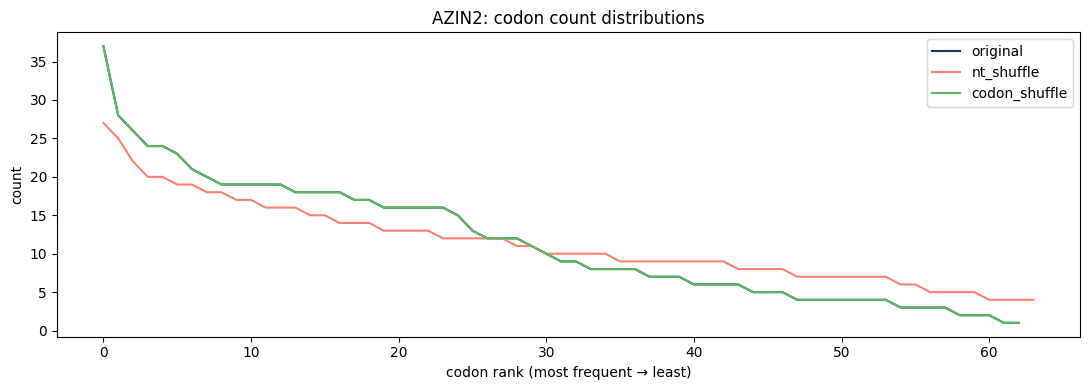

In [9]:
# Bar chart of codon-count rank distributions
fig, ax = plt.subplots(figsize=(11, 4))
for mode, colour in zip(['original', 'nt_shuffle', 'codon_shuffle'], ['#0d3b66', '#fa8072', '#5cb95c']):
    seq = concat_exonic(records[mode])
    n = (len(seq) // 3) * 3
    cnt = Counter(seq[i:i+3] for i in range(0, n, 3))
    sorted_counts = sorted(cnt.values(), reverse=True)
    ax.plot(range(len(sorted_counts)), sorted_counts, label=mode, color=colour, lw=1.5)
ax.set_xlabel('codon rank (most frequent → least)')
ax.set_ylabel('count')
ax.set_title(f'{GENE_NAME}: codon count distributions')
ax.legend()
plt.tight_layout()
plt.show()

## 7. The encoded one-hot input the model receives

The encoder pads the sense sequence with 5000 N's on each side, then carves it into 15 kb sliding windows where the central 5 kb carries the labels. Each window is `(15000, 4)` int8 (one-hot ACGT). We show the shape, then a small heatmap centred on the first donor of the gene so you can see what the model literally reads.

In [10]:
encoded_X = {}
encoded_Y = {}
for mode in MODES:
    X, Y = encode_one_gene(records[mode])
    encoded_X[mode] = X
    encoded_Y[mode] = Y[0]   # drop the leading length-1 axis
    print(f'{mode:14s} X={X.shape}  Y={Y[0].shape}  (windows × 15000 × 4  ;  windows × 5000 × 3)')

original       X=(8, 15000, 4)  Y=(8, 5000, 3)  (windows × 15000 × 4  ;  windows × 5000 × 3)
nt_shuffle     X=(8, 15000, 4)  Y=(8, 5000, 3)  (windows × 15000 × 4  ;  windows × 5000 × 3)
codon_shuffle  X=(8, 15000, 4)  Y=(8, 5000, 3)  (windows × 15000 × 4  ;  windows × 5000 × 3)
remove1        X=(8, 15000, 4)  Y=(8, 5000, 3)  (windows × 15000 × 4  ;  windows × 5000 × 3)
remove2        X=(8, 15000, 4)  Y=(8, 5000, 3)  (windows × 15000 × 4  ;  windows × 5000 × 3)


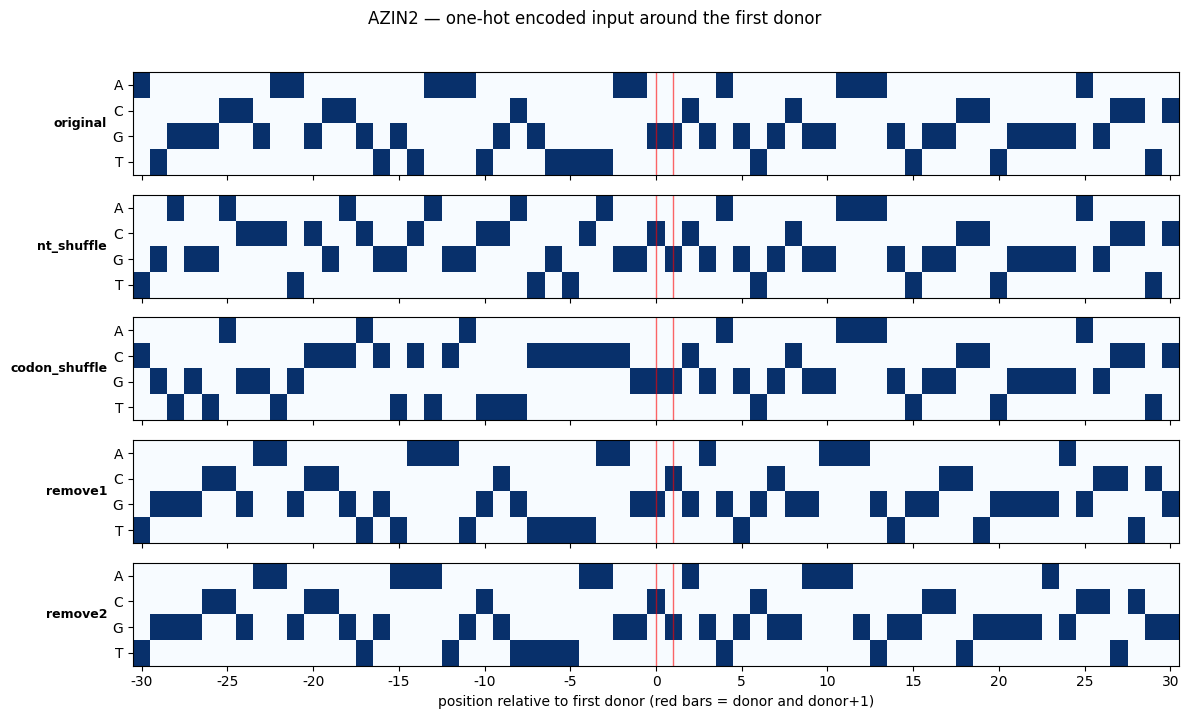

In [11]:
# Heatmap centred on first donor (sense pos = orig['donors'][0])
first_donor = orig['donors'][0]
window_idx = first_donor // 5000
pos_in_window = 5000 + (first_donor - window_idx * 5000)   # +5000 because labels live at [5000:10000] of each 15kb window
VIEW_HALF = 30

fig, axes = plt.subplots(len(MODES), 1, figsize=(12, 1.4 * len(MODES)), sharex=True)
for ax, mode in zip(axes, MODES):
    X = encoded_X[mode]
    if window_idx >= X.shape[0]:
        ax.set_visible(False); continue
    slab = X[window_idx, pos_in_window - VIEW_HALF: pos_in_window + VIEW_HALF + 1].T  # (4, 2*VIEW_HALF+1)
    ax.imshow(slab, aspect='auto', cmap='Blues', vmin=0, vmax=1, interpolation='nearest')
    ax.set_yticks(range(4)); ax.set_yticklabels(list('ACGT'))
    ax.set_ylabel(mode, rotation=0, ha='right', va='center', fontsize=9, fontweight='bold')
    ax.axvline(VIEW_HALF, color='red', lw=1, alpha=0.6)
    ax.axvline(VIEW_HALF + 1, color='red', lw=1, alpha=0.6)
axes[-1].set_xticks(range(0, 2 * VIEW_HALF + 1, 5))
axes[-1].set_xticklabels([str(x - VIEW_HALF) for x in range(0, 2 * VIEW_HALF + 1, 5)])
axes[-1].set_xlabel('position relative to first donor (red bars = donor and donor+1)')
fig.suptitle(f'{GENE_NAME} — one-hot encoded input around the first donor', y=1.02)
plt.tight_layout()
plt.show()

## 8. Labels (Y tensor) at the same window

Y is `(windows, 5000, 3)` one-hot: channel 0 = neither, 1 = acceptor, 2 = donor. We show the label region around the first donor for each mode. The donor at position 0 (red bar) should be 1 in the donor channel for every mode.

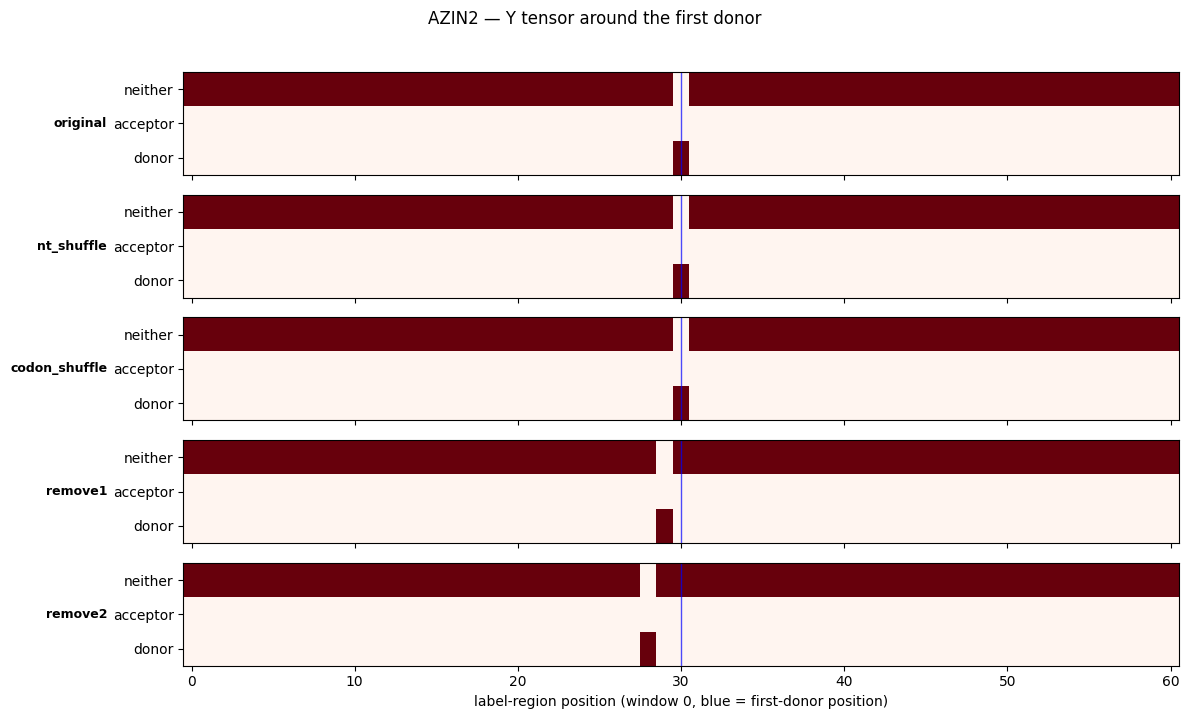

In [12]:
label_pos_in_window = first_donor - window_idx * 5000
fig, axes = plt.subplots(len(MODES), 1, figsize=(12, 1.4 * len(MODES)), sharex=True)
for ax, mode in zip(axes, MODES):
    Y = encoded_Y[mode]
    if window_idx >= Y.shape[0]:
        ax.set_visible(False); continue
    lo = max(0, label_pos_in_window - VIEW_HALF)
    hi = min(Y.shape[1], label_pos_in_window + VIEW_HALF + 1)
    slab = Y[window_idx, lo:hi].T   # (3, width)
    ax.imshow(slab, aspect='auto', cmap='Reds', vmin=0, vmax=1, interpolation='nearest')
    ax.set_yticks(range(3))
    ax.set_yticklabels(['neither', 'acceptor', 'donor'])
    ax.set_ylabel(mode, rotation=0, ha='right', va='center', fontsize=9, fontweight='bold')
    ax.axvline(label_pos_in_window - lo, color='blue', lw=1, alpha=0.7)
axes[-1].set_xlabel(f'label-region position (window {window_idx}, blue = first-donor position)')
fig.suptitle(f'{GENE_NAME} — Y tensor around the first donor', y=1.02)
plt.tight_layout()
plt.show()

## 9. Per-exon comparison across all modes

Render one chosen exon's actual nucleotide sequence in colour for every mode. Lets you eyeball, for that one exon, the difference between original / shuffled-by-nt / shuffled-by-codon / minus 1 nt / minus 2 nt.

In [13]:
EXON_IDX = 1   # which exon to inspect (0-indexed)
MAX_DISPLAY = 200

html_parts = ['<div style="font-family:monospace;font-size:11px;line-height:1.4">']
html_parts.append(f'<b>{GENE_NAME} exon {EXON_IDX + 1}</b><br><br>')
for mode in MODES:
    rec = records[mode]
    if EXON_IDX >= len(rec['exons']):
        html_parts.append(f'<b>{mode:14s}</b> (exon does not exist)<br><br>'); continue
    s, e = rec['exons'][EXON_IDX]
    seq = rec['sense'][s:e]
    snippet = seq[:MAX_DISPLAY]
    if mode == 'codon_shuffle':
        rendered = coloured_codon_html(snippet)
    else:
        rendered = coloured_seq_html(snippet)
    suffix = f'len={len(seq)}' + (' (truncated)' if len(seq) > MAX_DISPLAY else '')
    html_parts.append(f'<b>{mode:14s}</b>  {rendered}  &nbsp;<i>{suffix}</i><br><br>')
html_parts.append('</div>')
display(HTML(''.join(html_parts)))

## 10. Length summary

Quick cross-mode tally: how many bp of exonic content, how many junctions, total gene length.

In [14]:
print(f"{'mode':<14s}{'gene_len':>10s}{'#exons':>8s}{'#donors':>9s}{'#acceptors':>12s}{'Σ exonic':>11s}{'Σ intronic':>12s}")
print('-' * 76)
for mode in MODES:
    r = records[mode]
    exonic = sum(e - s for s, e in r['exons'])
    intronic = sum(a - d - 1 for d, a in zip(r['donors'], r['acceptors']))
    print(f"{mode:<14s}{r['gene_len']:>10,}{len(r['exons']):>8d}{len(r['donors']):>9d}{len(r['acceptors']):>12d}{exonic:>11,}{intronic:>12,}")

mode            gene_len  #exons  #donors  #acceptors   Σ exonic  Σ intronic
----------------------------------------------------------------------------
original          39,281      12       11          11      2,181      37,100
nt_shuffle        39,281      12       11          11      2,181      37,100
codon_shuffle     39,281      12       11          11      2,181      37,100
remove1           39,269      12       11          11      2,169      37,100
remove2           39,257      12       11          11      2,157      37,100
